In [ ]:
import pandas as pd
import numpy as np

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [8]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# データ分割
from sklearn.model_selection import train_test_split

# 線形モデル
from sklearn.ensemble import RandomForestClassifier

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

# 精度評価
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [20]:

plt.rcParams['font.family'] = 'MS Gothic' # Windows用 (Macの場合は 'AppleGothic')

In [9]:
train = pd.read_csv("C:\\Users\\ko.ameku.up\\Desktop\\kaggle_tutorial_zone\\data\\raw\\train.csv")
test = pd.read_csv("C:\\Users\\ko.ameku.up\\Desktop\\kaggle_tutorial_zone\\data\\raw\\test.csv")

In [10]:
train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.580499e+07,659.327400,37.840667,5.063600,42015.204376,1.589133,0.777467,0.490000,117746.962851,0.204000
std,4330.271354,1.278709e+07,72.475117,8.283259,2.781955,59280.633047,0.529850,0.415961,0.499917,45416.988057,0.402982
min,0.000000,1.578130e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,479.540000,0.000000
25%,3749.750000,1.563523e+07,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83056.220000,0.000000
50%,7499.500000,1.569017e+07,662.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122503.545000,0.000000
75%,11249.250000,1.575784e+07,709.000000,42.000000,7.000000,108465.955000,2.000000,1.000000,1.000000,156687.270000,0.000000
max,14999.000000,1.575404e+09,850.000000,72.000000,10.000000,187534.790000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [12]:
test.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,19999.50000,1.568976e+07,657.517400,37.801800,4.992000,43139.310800,1.587200,0.777600,0.498700,117099.339826
std,2886.89568,1.583061e+05,71.954009,8.259209,2.805588,60130.981846,0.532752,0.415879,0.500023,45732.020378
min,15000.00000,1.574712e+06,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,479.540000
25%,17499.75000,1.563187e+07,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82647.650000
50%,19999.50000,1.568887e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122925.400000
75%,22499.25000,1.575745e+07,707.000000,42.000000,7.000000,110939.957500,2.000000,1.000000,1.000000,155740.540000
max,24999.00000,1.581566e+07,850.000000,74.000000,10.000000,186796.370000,6.000000,1.000000,1.000000,199808.100000


In [11]:
corr_train = train.select_dtypes(exclude=object).corr()
corr_train

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,1.000000,-0.006421,-0.003445,-0.009531,-0.001737,-0.011291,0.001589,0.007743,-0.005379,-0.008949,-0.010120
CustomerId,-0.006421,1.000000,0.011982,-0.001798,0.004971,-0.005186,0.005585,0.004660,0.007504,0.005207,-0.002592
CreditScore,-0.003445,0.011982,1.000000,-0.025145,0.001854,0.013362,0.013108,0.007519,0.008626,-0.005544,-0.049330
Age,-0.009531,-0.001798,-0.025145,1.000000,-0.022683,0.078080,-0.166811,-0.002493,-0.039911,0.019568,0.460476
Tenure,-0.001737,0.004971,0.001854,-0.022683,1.000000,-0.017428,0.008095,-0.000501,-0.012678,0.011397,-0.028523
Balance,-0.011291,-0.005186,0.013362,0.078080,-0.017428,1.000000,-0.414656,-0.013819,-0.022482,0.015372,0.154272
NumOfProducts,0.001589,0.005585,0.013108,-0.166811,0.008095,-0.414656,1.000000,0.019217,0.059117,-0.011032,-0.311544
HasCrCard,0.007743,0.004660,0.007519,-0.002493,-0.000501,-0.013819,0.019217,1.000000,-0.019359,-0.012356,-0.005190
IsActiveMember,-0.005379,0.007504,0.008626,-0.039911,-0.012678,-0.022482,0.059117,-0.019359,1.000000,-0.023670,-0.206972
EstimatedSalary,-0.008949,0.005207,-0.005544,0.019568,0.011397,0.015372,-0.011032,-0.012356,-0.023670,1.000000,0.031559


In [13]:
corr_test = test.select_dtypes(exclude=object).corr()
corr_test

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
id,1.000000,-0.015311,-0.001439,-0.007409,0.008572,-0.006301,0.003904,0.005160,-0.003050,-0.001229
CustomerId,-0.015311,1.000000,-0.003457,-0.040814,0.012657,-0.015764,0.019760,-0.004151,0.020305,0.005941
CreditScore,-0.001439,-0.003457,1.000000,-0.027597,0.004327,-0.000571,0.016303,-0.005706,0.004016,0.002181
Age,-0.007409,-0.040814,-0.027597,1.000000,-0.016793,0.086476,-0.162380,-0.005992,-0.018394,0.006192
Tenure,0.008572,0.012657,0.004327,-0.016793,1.000000,-0.013563,-0.002678,-0.009068,-0.013624,0.015126
Balance,-0.006301,-0.015764,-0.000571,0.086476,-0.013563,1.000000,-0.419649,-0.002874,-0.015091,0.002840
NumOfProducts,0.003904,0.019760,0.016303,-0.162380,-0.002678,-0.419649,1.000000,0.002678,0.032149,-0.007597
HasCrCard,0.005160,-0.004151,-0.005706,-0.005992,-0.009068,-0.002874,0.002678,1.000000,-0.022071,-0.002984
IsActiveMember,-0.003050,0.020305,0.004016,-0.018394,-0.013624,-0.015091,0.032149,-0.022071,1.000000,-0.008622
EstimatedSalary,-0.001229,0.005941,0.002181,0.006192,0.015126,0.002840,-0.007597,-0.002984,-0.008622,1.000000


<Axes: >

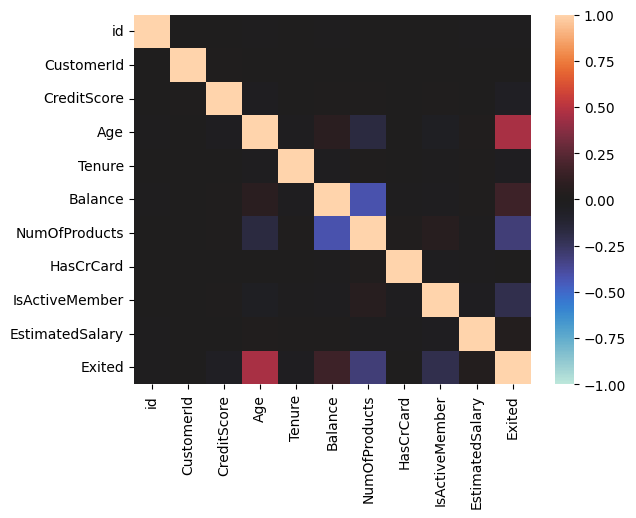

In [14]:
sns.heatmap(corr_train, vmax=1, vmin=-1, center=0)

<Axes: >

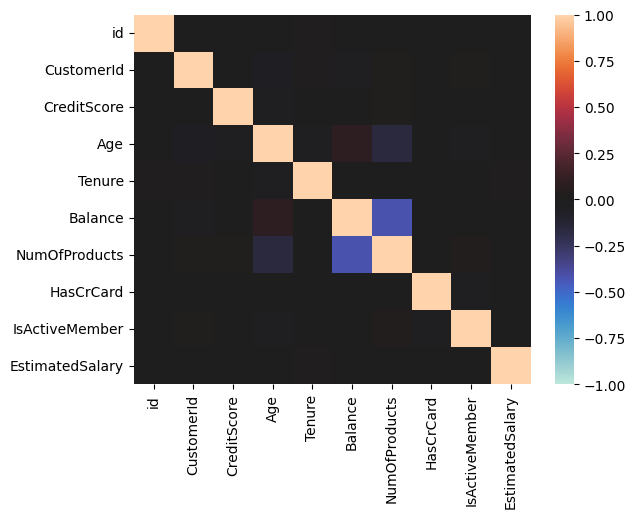

In [15]:
sns.heatmap(corr_test, vmax=1, vmin=-1, center=0)

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'CustomerId'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>],
       [<Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>, <Axes: >]], dtype=object)

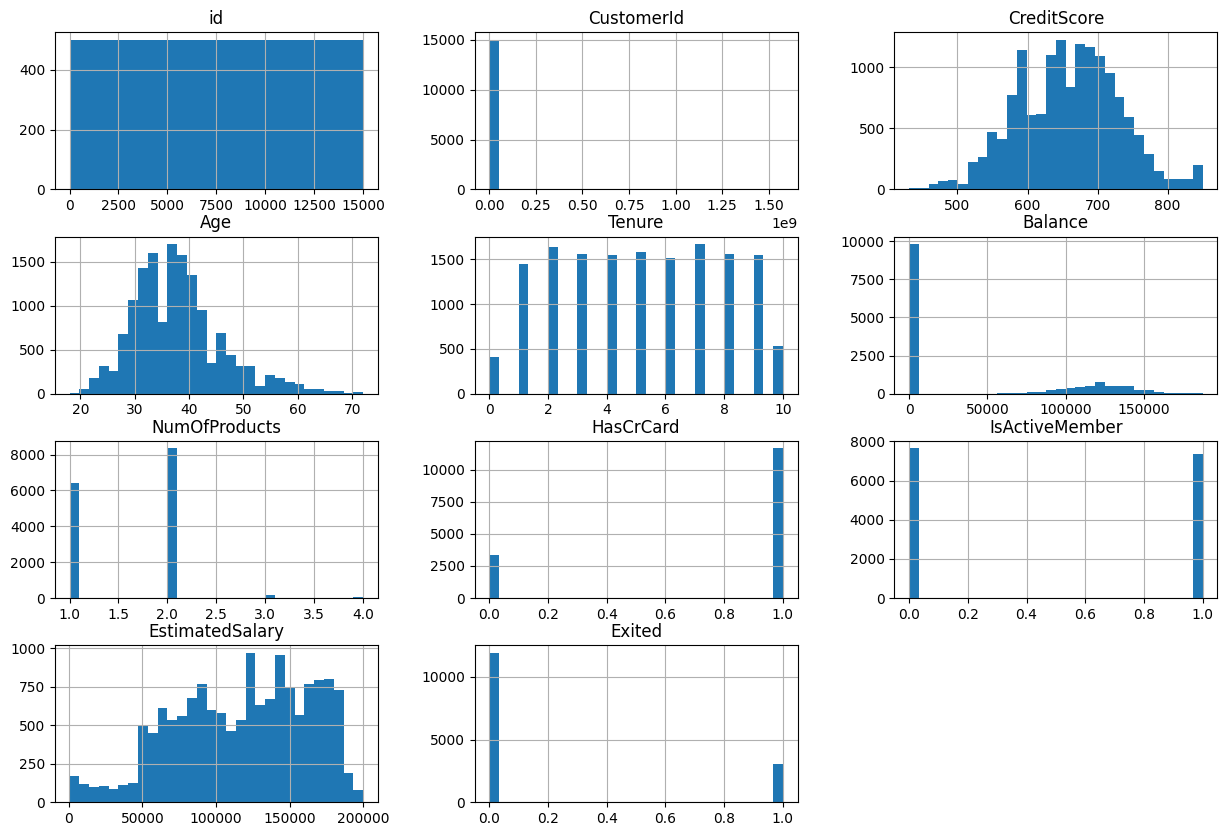

In [16]:
train.hist(bins=30, figsize=(15, 10))

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'CustomerId'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>],
       [<Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>, <Axes: >, <Axes: >]],
      dtype=object)

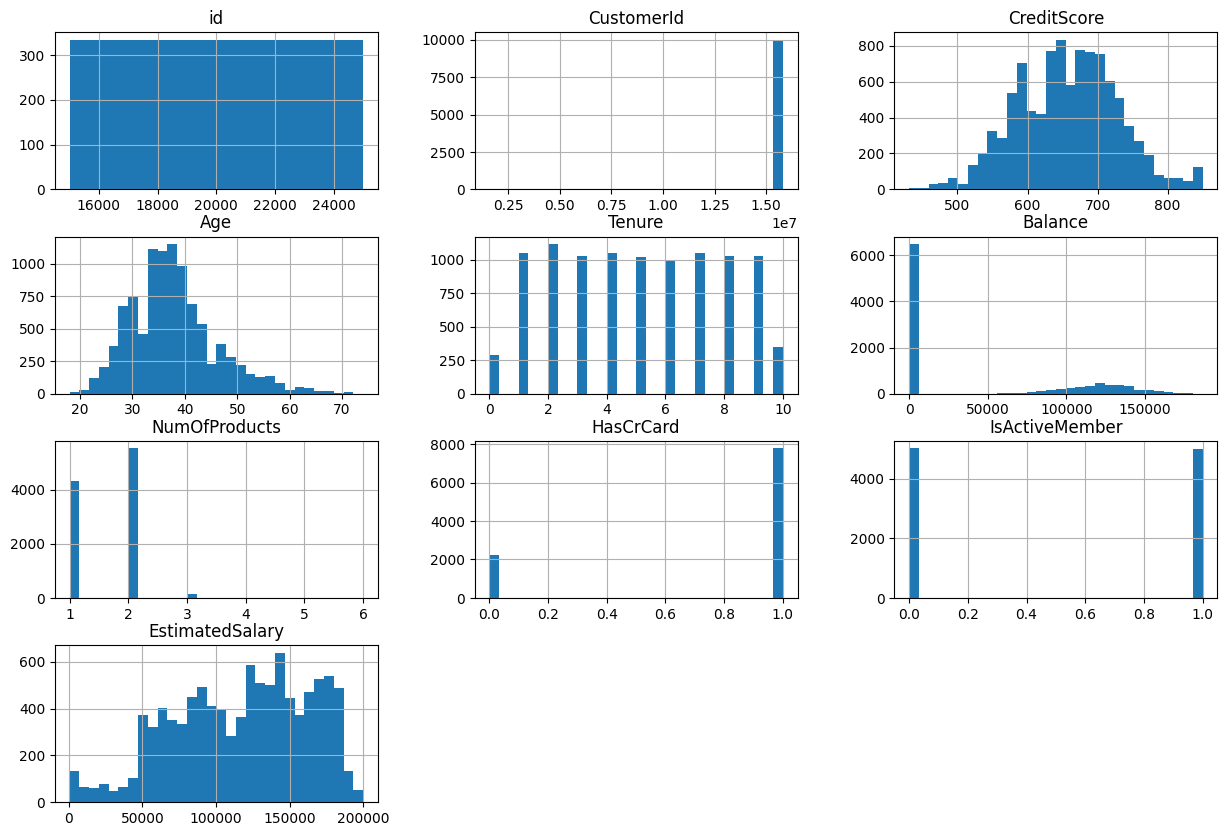

In [17]:
test.hist(bins=30, figsize=(15, 10))

In [ ]:
f,ax=plt.subplots(1,2,figsize=(19,8))
train['Exited'].value_counts().plot.pie(autopct='%1.1f%%',ax=ax[0],shadow=True)
# ax[0].set_title('Pie-Plot')
ax[0].set_ylabel('')
sns.countplot(x='Exited',data=train,ax=ax[1])
# ax[1].set_title('Count-Plot')
plt.suptitle('Target Value Anaysis - Competition Data')
plt.show()

In [18]:
# 3. 対象カラムの選定（id, CustomerId, Surname, 正解ラベル 以外）
target_cols = [
    'CreditScore', 'Geography', 'Gender', 'Age', 
    'Tenure', 'Balance', 'NumOfProducts', 
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
]


=== Geography の解約率クロス集計 ===
Exited           0.0        1.0
Geography                      
France     84.531542  15.468458
Germany    58.345588  41.654412
Spain      83.672193  16.327807

=== Gender の解約率クロス集計 ===
Exited        0.0        1.0
Gender                      
Female  71.578467  28.421533
Male    85.861823  14.138177

=== NumOfProducts の解約率クロス集計 ===
Exited               0.0        1.0
NumOfProducts                      
1.0            61.034107  38.965893
2.0            95.905663   4.094337
3.0             4.639175  95.360825
4.0             3.125000  96.875000

=== HasCrCard の解約率クロス集計 ===
Exited           0.0        1.0
HasCrCard                      
0.0        79.209107  20.790893
1.0        79.711885  20.288115

=== IsActiveMember の解約率クロス集計 ===
Exited                0.0        1.0
IsActiveMember                      
0.0             71.424837  28.575163
1.0             88.108844  11.891156


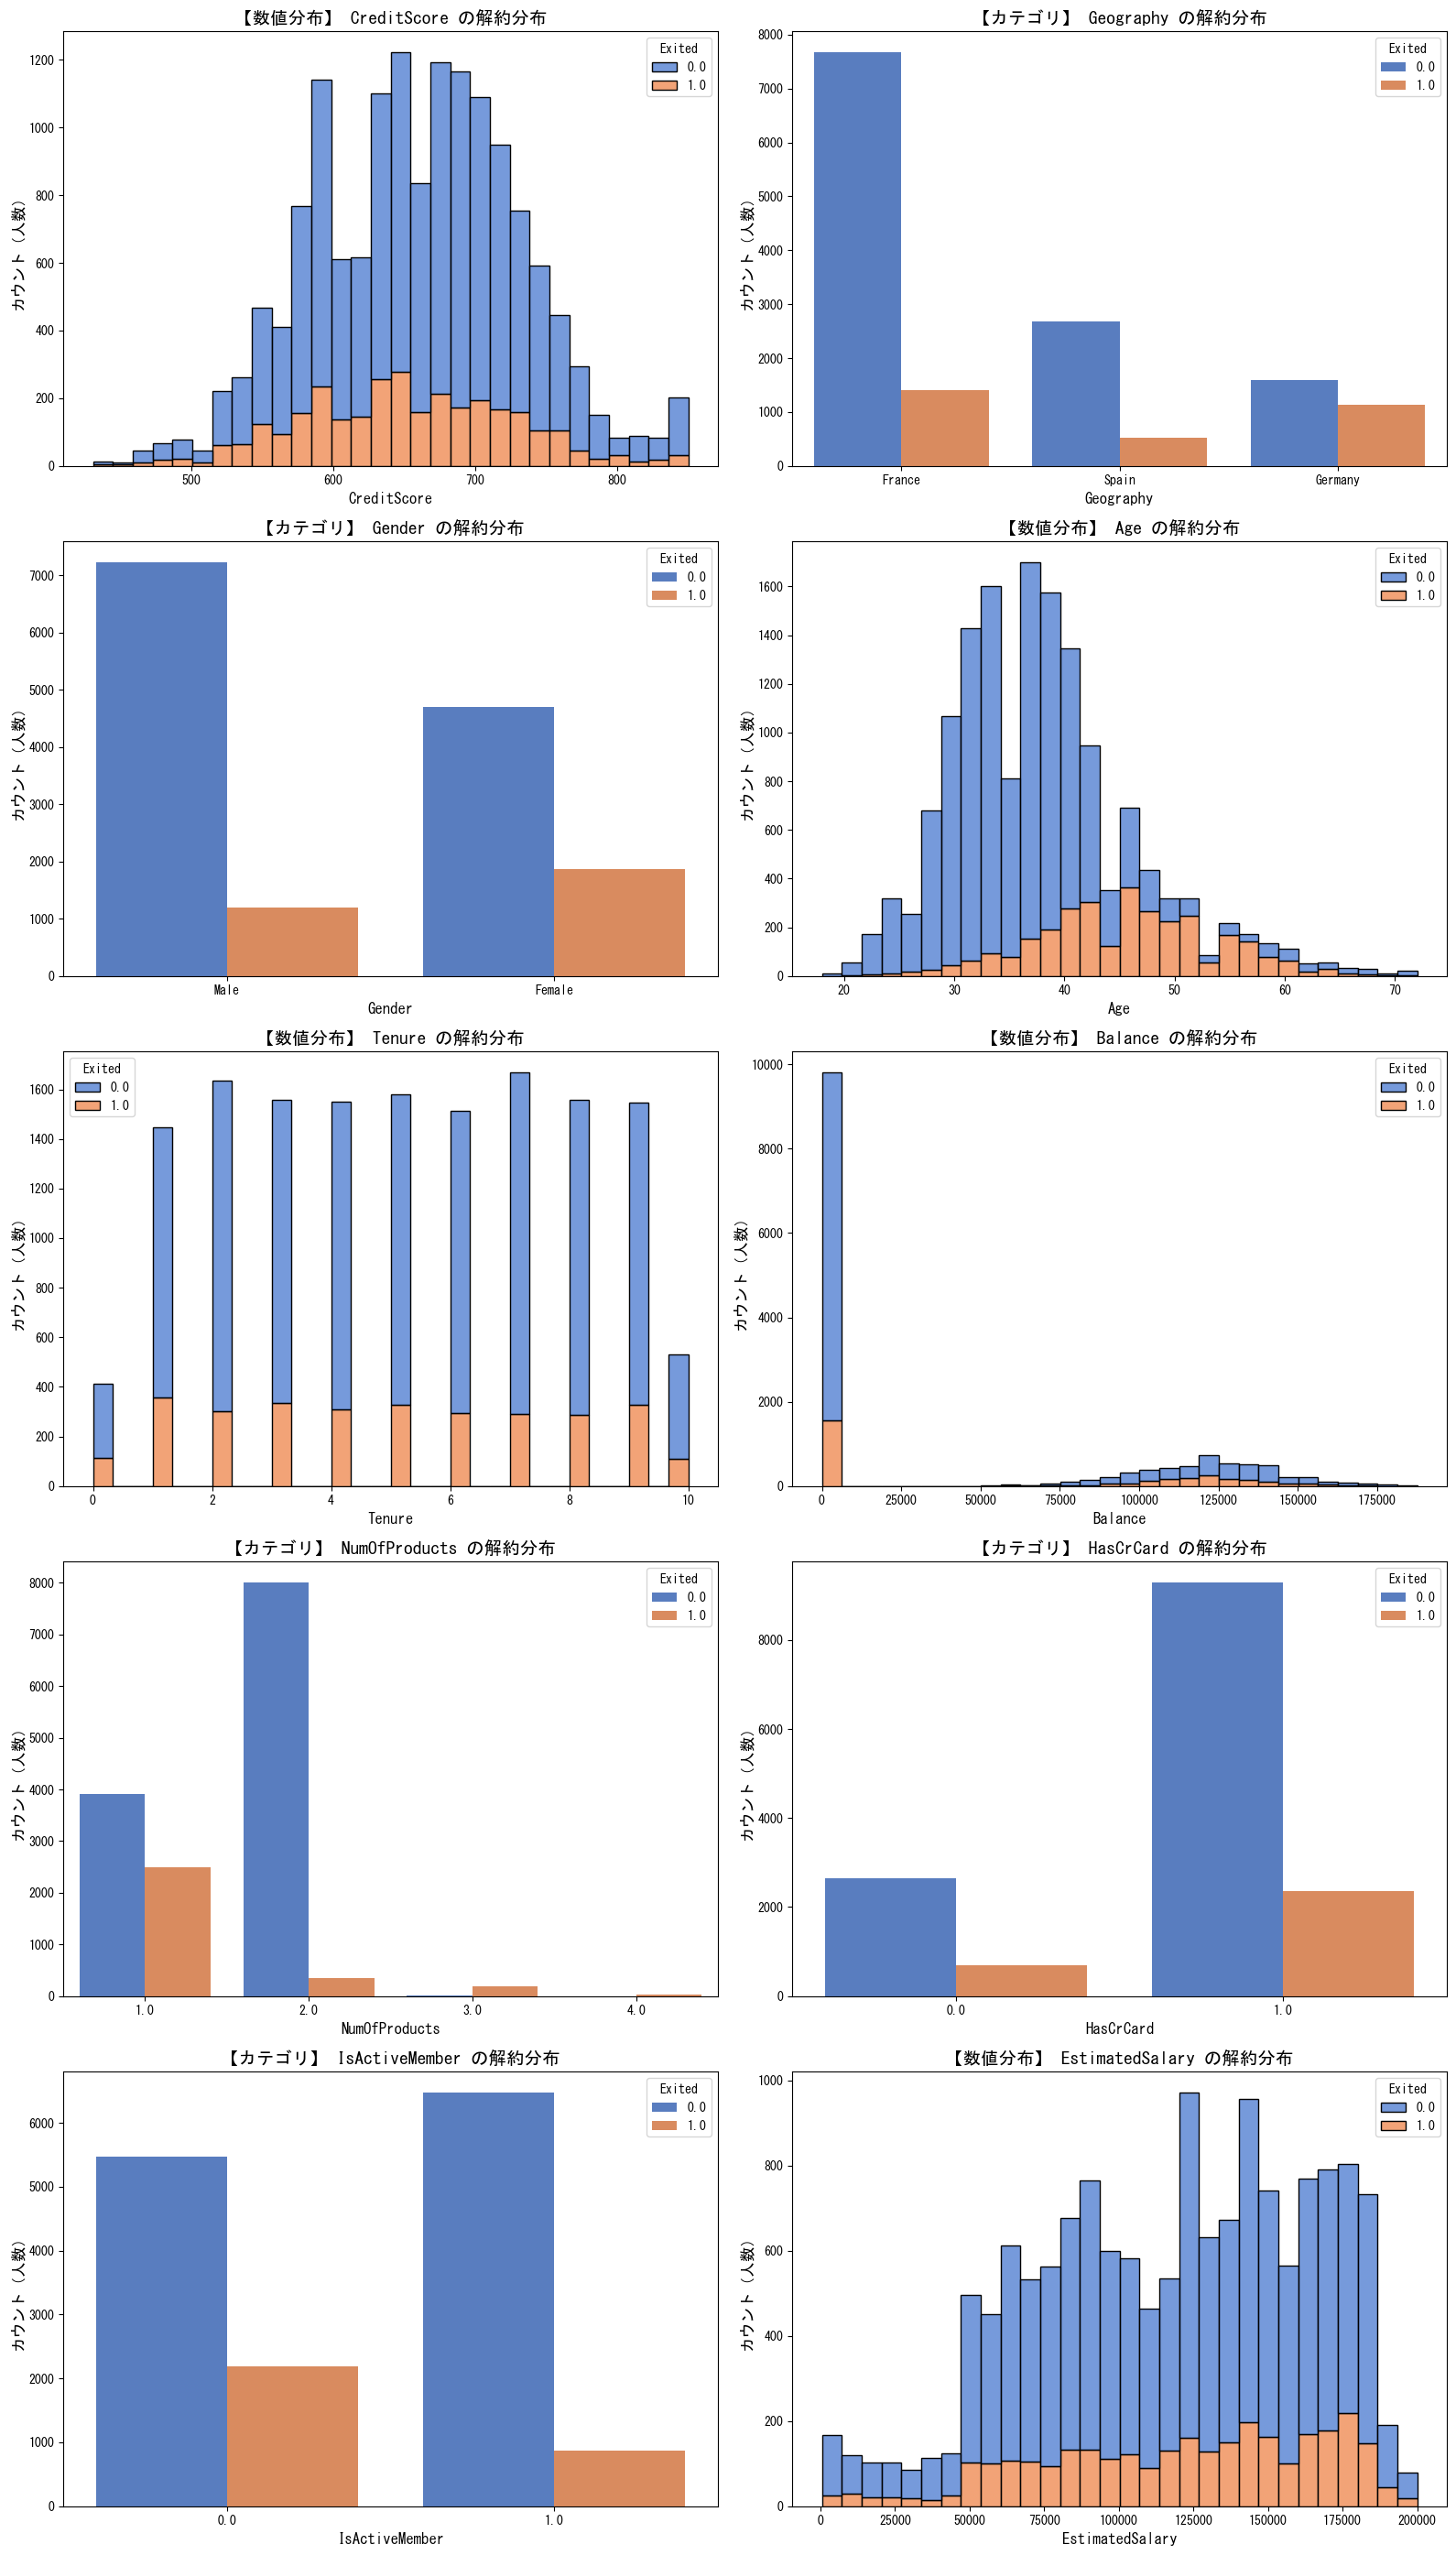

In [21]:
# 4. グラフの配置設定（5行2列で10個のカラムを並べる）
fig, axes = plt.subplots(5, 2, figsize=(16, 28))
axes = axes.flatten() # 2次元の配列を1次元に平坦化してループしやすくする

# 5. ループ処理で各カラムの分布を描画
for i, col in enumerate(target_cols):
    
    # 種類の数が少ないもの（国、性別、フラグ系、製品数など）は【カウントプロット】
    if train[col].nunique() <= 5:
        sns.countplot(
            data=train, 
            x=col, 
            hue='Exited', 
            ax=axes[i], 
            palette='muted'
        )
        axes[i].set_title(f'【カテゴリ】 {col} の解約分布', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('カウント（人数）', fontsize=12)
        
        # 数値としての割合もターミナル（ログ）に出力する
        print(f"\n=== {col} の解約率クロス集計 ===")
        print(pd.crosstab(train[col], train['Exited'], normalize='index') * 100)
        
    # 種類の数が多い連続値（年齢、残高、年収、スコア）は【ヒストグラム】
    else:
        sns.histplot(
            data=train, 
            x=col, 
            hue='Exited', 
            multiple='stack', # 解約と継続を積み上げる形式
            ax=axes[i], 
            bins=30, 
            palette='muted'
        )
        axes[i].set_title(f'【数値分布】 {col} の解約分布', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('カウント（人数）', fontsize=12)
# レイアウトを綺麗に整えて表示
plt.tight_layout()
plt.show()

# グラフを画像として保存したい場合（コメントアウトを解除してください）
# plt.savefig('all_columns_distribution.png', dpi=100)